In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add helpers path
sys.path.append("/mnt/home/csun1/scripts/global_scripts/imports")

try:
    from helpers.init import *
    import helpers.font as hf
    hf.set_font_family("Google Sans")
except ImportError:
    # Fallback if helpers not found during execution (unlikely given find result)
    print("Warning: helpers not found, using standard matplotlib")
    class DummyFont:
        def __getattr__(self, name): return None
    hf = DummyFont()

os.chdir("/mnt/home/csun1/ceph/util/pymagical")

# Load data
perf_df = pd.read_csv("benchmark_performance.csv")
conv_df = pd.read_csv("benchmark_convergence.csv")

datasets = sorted([ds for ds in perf_df["Dataset"].unique() if ds != "endothelial"])
impl_map = {"matlab": "MATLAB", "numpy": "NumPy", "numba": "Numba"}

In [96]:
# --- Plot 1: Speed per Celltype ---
fig, axes = plt.subplots(3, 2, figsize=(4, 4.5), dpi=300, layout="tight") # Increased height slightly for legend
axes_flat = axes.flatten()

for i, ds in enumerate(datasets):
    ax = axes_flat[i]
    df_ds = perf_df[perf_df["Dataset"] == ds].copy()
    df_ds["Implementation"] = df_ds["Implementation"].map(impl_map)
    
    sns.lineplot(data=df_ds, x="Iterations", y="Gibbs_Time", hue="Implementation", 
                 marker="s", markersize=4, ax=ax, linewidth=1.5, palette=['grey', 'cornflowerblue', 'dodgerblue'])
    
    ax.set_yscale("log")
    ax.set_title(f'{ds.replace("_", " ").title()}', loc='left', fontproperties=hf.sf)
    ax.set_xlabel("Iterations", fontproperties=hf.sf)
    ax.set_ylabel("Time (s)", fontproperties=hf.sf)
    
    # Always remove the local legend
    ax.get_legend().remove()
    
    [l.set_fontproperties(hf.sf) for l in ax.get_yticklabels()]
    [l.set_fontproperties(hf.sf) for l in ax.get_xticklabels()]

# Hide empty subplots
for j in range(len(datasets), len(axes_flat)):
    axes_flat[j].axis('off')

# Extract handles and labels from the last active axis for the global legend
handles, labels = ax.get_legend_handles_labels()

# Create the figure-level legend
fig.legend(handles, labels, 
           loc='upper right', 
           bbox_to_anchor=(1,1), # Adjust -0.05 if it's too close/far
           ncol=len(labels),            # Puts labels in one row
           prop=hf.sf,
           borderaxespad=0)

fig.suptitle("Optimized MAGICAL Runtimes", 
             fontproperties=hf.mf, x=0, y=1, ha='left', va='top')

sns.despine()
plt.close()

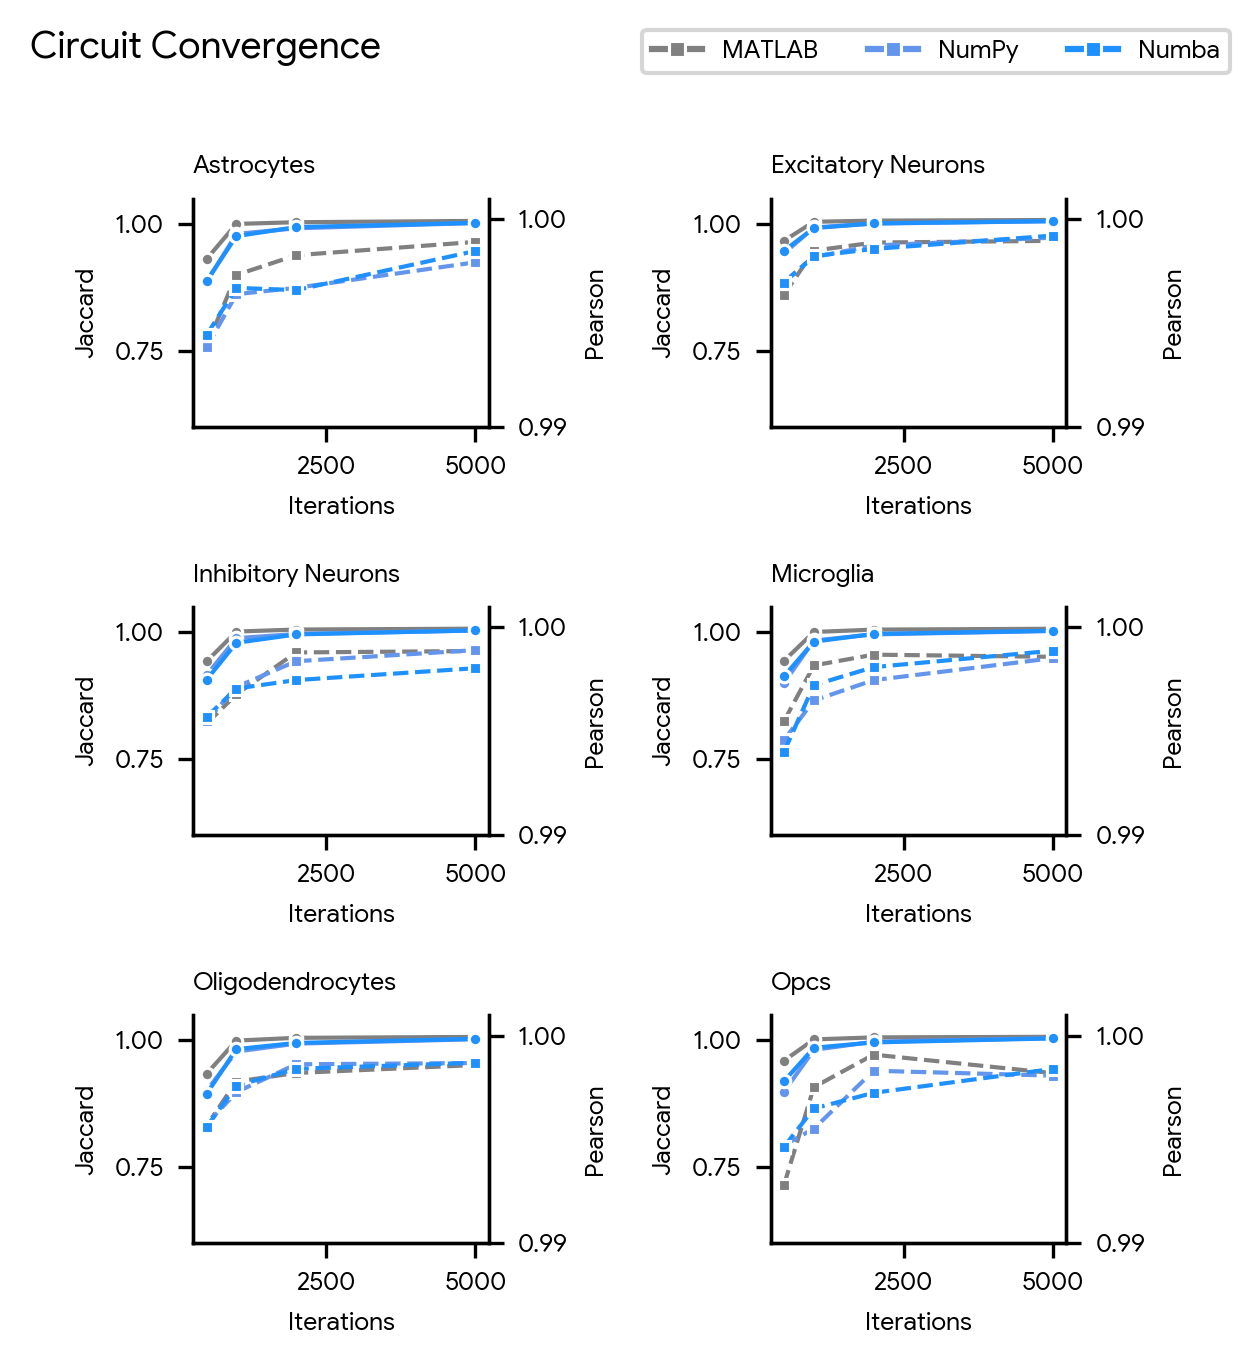

In [100]:
impl_palette = ['grey', 'cornflowerblue', 'dodgerblue']
# --- Plot 2: Convergence per Celltype ---
iter_pair_map = {"100_vs_500": 500, "500_vs_1000": 1000, "1000_vs_2000": 2000, "2000_vs_5000": 5000}
fig2, axes2 = plt.subplots(3, 2, figsize=(4, 4.5), dpi=300, layout="tight")
axes_flat2 = axes2.flatten()

for i, ds in enumerate(datasets):
	ax1 = axes_flat2[i]
	df_ds = conv_df[conv_df["Dataset"] == ds].copy()
	df_ds["Higher_Iter"] = df_ds["Iter_Pair"].map(iter_pair_map)
	df_ds["Implementation"] = df_ds["Implementation"].map(impl_map)
	
	# Left Axis: Jaccard
	sns.lineplot(data=df_ds, x="Higher_Iter", y="Jaccard_Converge", hue="Implementation", 
					marker="s", markersize=3, linestyle="--", ax=ax1, linewidth=1, palette=impl_palette, legend=False)
	
	ax1.set_title(f'{ds.replace("_", " ").title()}', loc='left', fontproperties=hf.sf)
	ax1.set_xlabel("Iterations", fontproperties=hf.sf)
	ax1.set_ylabel("Jaccard", color='black', fontproperties=hf.sf)
	ax1.set_ylim(0.6, 1.05)
	
	[l.set_fontproperties(hf.sf) for l in ax1.get_yticklabels()]
	[l.set_fontproperties(hf.sf) for l in ax1.get_xticklabels()]

	# Right Axis: Pearson
	ax2 = ax1.twinx()
	sns.lineplot(data=df_ds, x="Higher_Iter", y="L_Corr_Converge", hue="Implementation", 
					marker="o", markersize=3, ax=ax2, linewidth=1, palette=impl_palette, legend=False)
	ax2.set_ylabel("Pearson", color='black', fontproperties=hf.sf)
	ax2.set_ylim(0.99, 1.001) 
	
	[l.set_fontproperties(hf.sf) for l in ax2.get_yticklabels()]

for j in range(len(datasets), len(axes_flat2)):
	axes_flat2[j].axis('off')

fig2.legend(handles, labels, 
		loc='upper right', 
		bbox_to_anchor=(1,1), 
		ncol=len(labels),            
		prop=hf.sf,
		borderaxespad=0)

fig2.suptitle("Circuit Convergence", 
				fontproperties=hf.mf, x=0, y=1, ha='left', va='top')

sns.despine(fig=fig2, right=False)